<a href="https://colab.research.google.com/github/Dentriciche/Project_SP/blob/main/03%20-%20Model%20Building/transformer_bert_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT-style Transformer for South Park Character Classification

This notebook implements a custom BERT-style transformer encoder for predicting which South Park character spoke a given line of dialogue.

## Why Transformers?

Transformers have revolutionized NLP by addressing key limitations of RNNs:

- **Parallel Processing** - Unlike RNNs, transformers process entire sequences simultaneously
- **Long-range Dependencies** - Self-attention captures relationships between any two tokens
- **No Vanishing Gradients** - Direct connections between all positions
- **Bidirectional Context** - Understands context from both directions simultaneously

### BERT Architecture:

Our implementation follows BERT's encoder-only design:
1. **Token + Positional Embeddings** - Encode words and their positions
2. **Multi-Head Self-Attention** - Learn different aspects of relationships
3. **Feed-Forward Networks** - Process attended representations
4. **Layer Normalization + Residual Connections** - Stable training
5. **[CLS] Token Classification** - Use first token for sequence classification

For character classification, we expect transformers to capture:
- **Character-specific phrases** - Cartman: Respect my authority
- **Speaking patterns** - Stan: Dude, this is...
- **Contextual nuances** - Word order and emphasis matter

## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR

import pandas as pd
import numpy as np
import re
from collections import Counter
from typing import List, Dict, Tuple

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Configuration Parameters

In [2]:
# Dataset configuration
K = 31

# Transformer hyperparameters
EMBEDDING_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 4
HIDDEN_DIM = 512
MAX_SEQ_LEN = 256
DROPOUT_RATE = 0.2

# Training hyperparameters
BATCH_SIZE = 12
LEARNING_RATE = 1e-4
MAX_LR = 5e-4
NUM_EPOCHS = 50
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.1

# Early stopping
EARLY_STOP_PATIENCE = 7

# Text preprocessing
MIN_WORD_FREQ = 2
MAX_VOCAB_SIZE = 10000

# Data split ratios
VAL_SIZE = 0.15
TEST_SIZE = 0.15

print(f"Configuration:")
print(f"  Top K characters: {K}")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Num attention heads: {NUM_HEADS}")
print(f"  Num transformer layers: {NUM_LAYERS}")
print(f"  Feedforward dim: {HIDDEN_DIM}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Dropout rate: {DROPOUT_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE} -> {MAX_LR}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {EARLY_STOP_PATIENCE}")
print(f"  Label smoothing: {LABEL_SMOOTHING}")

Configuration:
  Top K characters: 31
  Embedding dim: 128
  Num attention heads: 4
  Num transformer layers: 4
  Feedforward dim: 512
  Max sequence length: 256
  Dropout rate: 0.2
  Batch size: 12
  Learning rate: 0.0001 -> 0.0005
  Max epochs: 50
  Early stopping patience: 7
  Label smoothing: 0.1


## 3. Load Data

In [3]:
# Load South Park dialogue data from GitHub (seasons 1-19)
base_url = "https://raw.githubusercontent.com/BobAdamsEE/SouthParkData/refs/heads/master/by-season/Season-{}.csv"

print("Loading South Park dialogue data...")
dfs = []
for season in tqdm(range(1, 20), desc="Loading seasons"):
    url = base_url.format(season)
    dfs.append(pd.read_csv(url))

df = pd.concat(dfs, ignore_index=True)
print(f"Total lines loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading South Park dialogue data...


Loading seasons: 100%|██████████| 19/19 [00:03<00:00,  5.85it/s]


Total lines loaded: 73,139
Columns: ['Season', 'Episode', 'Character', 'Line']

First few rows:


,Season,Episode,Character,Line
0,1,1,Boys,"School day, school day, teacher's golden ru...\n"
1,1,1,Kyle,"Ah, damn it! My little brother's trying to fol..."
2,1,1,Ike,Zeeponanner.\n
3,1,1,Kyle,"Ike, you can't come to school with me. \n"
4,1,1,Cartman,"Yeah, go home you little dildo.\n"


## 4. Data Cleaning and Character Selection

In [12]:
# Clean data
df = df.dropna(subset=['Character', 'Line'])
df = df[df['Line'].str.strip() != '']

# Count character frequencies
char_counts = df['Character'].value_counts()
print(f"Total unique characters: {len(char_counts)}")
print(f"\nTop {K} characters:")
print(char_counts.head(K))

# Select top K characters
top_k_chars = char_counts.head(K).index.tolist()
df_filtered = df[df['Character'].isin(top_k_chars)].copy()

print(f"\nFiltered dataset size: {len(df_filtered):,} lines")
print(f"Percentage of original data: {100 * len(df_filtered) / len(df):.2f}%")

Total unique characters: 4055

Top 31 characters:
Character
Cartman               10021
Stan                   7775
Kyle                   7233
Butters                2717
Randy                  2663
Mr. Garrison           1083
Chef                    918
Kenny                   895
Sharon                  891
Jimmy                   682
Gerald                  662
Mr. Mackey              652
Liane                   602
Wendy                   594
Sheila                  571
Jimbo                   562
Announcer               413
Stephen                 377
Craig                   361
Clyde                   322
Jesus                   312
Principal Victoria      302
Token                   292
Linda                   290
Mrs. Garrison           282
Terrance                282
Tweek                   269
Timmy                   263
Mayor                   245
Phillip                 222
Bebe                    221
Name: count, dtype: int64

Filtered dataset size: 42,974 lines
Percentag

## 5. Create Label Mappings and Split Data

In [13]:
# Create character to label mappings
char_to_label = {char: idx for idx, char in enumerate(top_k_chars)}
label_to_char = {idx: char for char, idx in char_to_label.items()}

print("Character to label mapping:")
for char, label in char_to_label.items():
    print(f"  {label}: {char}")

# Extract texts and labels
texts = df_filtered['Line'].tolist()
labels = df_filtered['Character'].map(char_to_label).tolist()

# Stratified train/val/test split
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    texts, labels, test_size=TEST_SIZE, stratify=labels, random_state=42
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    stratify=train_val_labels,
    random_state=42
)

print(f"\nData split:")
print(f"  Train: {len(train_texts):,} samples")
print(f"  Val:   {len(val_texts):,} samples")
print(f"  Test:  {len(test_texts):,} samples")

Character to label mapping:
  0: Cartman
  1: Stan
  2: Kyle
  3: Butters
  4: Randy
  5: Mr. Garrison
  6: Chef
  7: Kenny
  8: Sharon
  9: Jimmy
  10: Gerald
  11: Mr. Mackey
  12: Liane
  13: Wendy
  14: Sheila
  15: Jimbo
  16: Announcer
  17: Stephen
  18: Craig
  19: Clyde
  20: Jesus
  21: Principal Victoria
  22: Token
  23: Linda
  24: Mrs. Garrison
  25: Terrance
  26: Tweek
  27: Timmy
  28: Mayor
  29: Phillip
  30: Bebe

Data split:
  Train: 30,081 samples
  Val:   6,446 samples
  Test:  6,447 samples


## 6. Text Preprocessing and Vocabulary\n\nFor BERT-style transformers, we need special tokens:\n- `<pad>` - Padding token (index 0)\n- `<unk>` - Unknown words (index 1)\n- `<cls>` - Classification token (index 2) - prepended to every sequence\n- `<sep>` - Separator token (index 3) - optional for single sentences

In [14]:
def preprocess_text(text: str) -> List[str]:
    """Clean and tokenize text."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return tokens


class Vocabulary:
    """Vocabulary with special tokens for BERT-style models."""

    def __init__(self, min_freq=1, max_size=None):
        self.min_freq = min_freq
        self.max_size = max_size
        self.word2idx = {'<pad>': 0, '<unk>': 1, '<cls>': 2, '<sep>': 3}
        self.idx2word = {0: '<pad>', 1: '<unk>', 2: '<cls>', 3: '<sep>'}
        self.word_counts = Counter()

    def build_vocab(self, texts: List[List[str]]):
        """Build vocabulary from tokenized texts."""
        for tokens in texts:
            self.word_counts.update(tokens)

        # Filter by frequency
        filtered_words = {w: c for w, c in self.word_counts.items() if c >= self.min_freq}

        # Sort by frequency
        sorted_words = sorted(filtered_words.items(), key=lambda x: x[1], reverse=True)

        # Limit vocabulary size
        if self.max_size:
            sorted_words = sorted_words[:self.max_size - 4]  # Reserve space for special tokens

        # Add to vocabulary
        for word, _ in sorted_words:
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, tokens: List[str]) -> List[int]:
        """Convert tokens to indices."""
        return [self.word2idx.get(token, self.word2idx['<unk>']) for token in tokens]

    def decode(self, indices: List[int]) -> List[str]:
        """Convert indices to tokens."""
        return [self.idx2word.get(idx, '<unk>') for idx in indices]

    def __len__(self):
        return len(self.word2idx)


# Preprocess all texts
print("Preprocessing texts...")
train_tokens = [preprocess_text(text) for text in tqdm(train_texts, desc="Train")]
val_tokens = [preprocess_text(text) for text in tqdm(val_texts, desc="Val")]
test_tokens = [preprocess_text(text) for text in tqdm(test_texts, desc="Test")]

# Build vocabulary
vocab = Vocabulary(min_freq=MIN_WORD_FREQ)
vocab.build_vocab(train_tokens)

print(f"\nVocabulary size: {len(vocab):,}")
print(f"Special tokens: <pad>={vocab.word2idx['<pad>']}, <unk>={vocab.word2idx['<unk>']}, <cls>={vocab.word2idx['<cls>']}, <sep>={vocab.word2idx['<sep>']}")
print(f"\nMost common words:")
for word, count in vocab.word_counts.most_common(10):
    print(f"  {word}: {count}")

Preprocessing texts...


Test: 100%|██████████| 6447/6447 [00:00<00:00, 128600.40it/s]



Vocabulary size: 8,062
Special tokens: <pad>=0, <unk>=1, <cls>=2, <sep>=3

Most common words:
  you: 10697
  the: 9275
  i: 8160
  to: 7942
  a: 5934
  and: 5238
  it: 4393
  that: 3837
  is: 3773
  we: 3735


## 7. Dataset and DataLoader\n\nFor BERT-style models, we prepend the `<cls>` token to each sequence and create attention masks.

In [15]:
class DialogueDataset(Dataset):
    """Dataset for dialogue classification with BERT-style preprocessing."""

    def __init__(self, tokens_list, labels, vocab, max_len):
        self.tokens_list = tokens_list
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        self.cls_idx = vocab.word2idx['<cls>']

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = self.tokens_list[idx]
        label = self.labels[idx]

        # Encode tokens
        token_ids = self.vocab.encode(tokens)

        # Prepend [CLS] token and truncate to max_len - 1
        token_ids = [self.cls_idx] + token_ids[:self.max_len - 1]

        # Get actual length
        length = len(token_ids)

        return {
            'input_ids': token_ids,
            'label': label,
            'length': length
        }


def collate_fn(batch):
    """Collate function with padding and attention masks."""
    input_ids = [item['input_ids'] for item in batch]
    labels = [item['label'] for item in batch]
    lengths = [item['length'] for item in batch]

    # Pad sequences
    max_len = max(lengths)
    padded_input_ids = []
    attention_masks = []

    for ids, length in zip(input_ids, lengths):
        # Pad input_ids
        padding_length = max_len - length
        padded_ids = ids + [0] * padding_length
        padded_input_ids.append(padded_ids)

        # Create attention mask (1 for real tokens, 0 for padding)
        mask = [1] * length + [0] * padding_length
        attention_masks.append(mask)

    return {
        'input_ids': torch.tensor(padded_input_ids, dtype=torch.long),
        'attention_mask': torch.tensor(attention_masks, dtype=torch.long),
        'labels': torch.tensor(labels, dtype=torch.long),
        'lengths': torch.tensor(lengths, dtype=torch.long)
    }


# Create datasets
train_dataset = DialogueDataset(train_tokens, train_labels, vocab, MAX_SEQ_LEN)
val_dataset = DialogueDataset(val_tokens, val_labels, vocab, MAX_SEQ_LEN)
test_dataset = DialogueDataset(test_tokens, test_labels, vocab, MAX_SEQ_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  Test batches: {len(test_loader)}")

# Test a batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  input_ids: {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")
print(f"  labels: {sample_batch['labels'].shape}")
print(f"\nFirst sequence (with [CLS]):")
print(f"  Tokens: {vocab.decode(sample_batch['input_ids'][0].tolist()[:20])}")

Train batches: 2507  Val batches: 538  Test batches: 538

Sample batch shapes:
  input_ids: torch.Size([12, 22])
  attention_mask: torch.Size([12, 22])
  labels: torch.Size([12])

First sequence (with [CLS]):
  Tokens: ['<cls>', 'thats', 'right', 'so', 'now', 'you', 'can', 'pay', 'us', 'to', 'use', 'him', 'in', 'your', 'commercials', 'and', 'youll', 'have', 'your', 'very']


## 8. BERT-style Transformer Model Architecture
We implement a custom BERT-style transformer encoder using PyTorch's built-in components:

1. **Token Embeddings**
- Convert word indices to dense vectors
2. **Positional Embeddings**
- Add position information (learned, not sinusoidal)3. **Transformer Encoder** - Multi-head self-attention + feedforward layers
4. **Classification Head**
- Use [CLS] token representation for prediction

Key differences from RNN/LSTM:\n- **Parallel processing**
- All tokens processed simultaneously
- **Self-attention** - Each token attends to all other tokens
- **Positional encoding**
- Explicit position information (RNNs get this implicitly)
- **No recurrence** - No hidden state passed between time steps

In [16]:
class TransformerClassifier(nn.Module):
    """BERT-style transformer encoder for sequence classification."""

    def __init__(self, vocab_size, embedding_dim=128, num_heads=4,
                 num_layers=4, hidden_dim=512, num_classes=12,
                 max_seq_len=256, dropout=0.2):
        super(TransformerClassifier, self).__init__()

        self.embedding_dim = embedding_dim
        self.max_seq_len = max_seq_len

        # Token embeddings
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Positional embeddings (learned, not sinusoidal like original Transformer)
        self.pos_embedding = nn.Embedding(max_seq_len, embedding_dim)

        # Dropout for embeddings
        self.embedding_dropout = nn.Dropout(dropout)

        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            activation='gelu',  # GELU activation like BERT
            batch_first=True,
            norm_first=False  # Post-norm like original Transformer
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head (like BERT)
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize weights following BERT initialization."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                module.weight.data.normal_(mean=0.0, std=0.02)
                if module.bias is not None:
                    module.bias.data.zero_()
            elif isinstance(module, nn.Embedding):
                module.weight.data.normal_(mean=0.0, std=0.02)
                if module.padding_idx is not None:
                    module.weight.data[module.padding_idx].zero_()

    def forward(self, input_ids, attention_mask=None):
        """
        Forward pass.

        Args:
            input_ids: (batch_size, seq_len) - Token indices
            attention_mask: (batch_size, seq_len) - 1 for real tokens, 0 for padding

        Returns:
            logits: (batch_size, num_classes) - Classification logits
        """
        batch_size, seq_len = input_ids.size()

        # Create position indices
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)

        # Token + positional embeddings
        token_embeds = self.token_embedding(input_ids)
        pos_embeds = self.pos_embedding(positions)
        embeddings = token_embeds + pos_embeds
        embeddings = self.embedding_dropout(embeddings)

        # Create padding mask for transformer (True for padding, False for real tokens)
        # PyTorch transformer expects True for positions to IGNORE
        if attention_mask is not None:
            padding_mask = (attention_mask == 0)
        else:
            padding_mask = None

        # Transformer encoding
        encoded = self.transformer(embeddings, src_key_padding_mask=padding_mask)

        # Use [CLS] token (first token) for classification
        cls_output = encoded[:, 0, :]  # (batch_size, embedding_dim)

        # Classification
        logits = self.classifier(cls_output)

        return logits


# Initialize model
model = TransformerClassifier(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    hidden_dim=HIDDEN_DIM,
    num_classes=K,
    max_seq_len=MAX_SEQ_LEN,
    dropout=DROPOUT_RATE
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Model initialized
Total parameters: 1,939,743
Trainable parameters: 1,939,743

Model architecture:
TransformerClassifier(
  (token_embedding): Embedding(8062, 128, padding_idx=0)
  (pos_embedding): Embedding(256, 128)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Sequ

## 9. Class Weights

In [17]:
# Compute balanced class weights
class_weights = compute_class_weight('balanced', classes=np.arange(K), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights computed")
print(f"Class weights: {class_weights}")
print(f"\nWeight range: {class_weights.min():.3f} - {class_weights.max():.3f}")

Class weights computed
Class weights: tensor([0.1383, 0.1783, 0.1917, 0.5104, 0.5209, 1.2802, 1.5115, 1.5476, 1.5576,
        2.0300, 2.0913, 2.1280, 2.2994, 2.3326, 2.4320, 2.4628, 3.3576, 3.6896,
        3.8354, 4.2936, 4.4512, 4.5771, 4.7566, 4.8037, 4.9008, 4.9008, 5.1615,
        5.2737, 5.6746, 6.2202, 6.2604])

Weight range: 0.138 - 6.260


## 10. Training Function with Early Stopping\n\nTraining enhancements for transformers:\n- **AdamW optimizer** - Adam with decoupled weight decay (better for transformers)\n- **OneCycleLR scheduler** - Learning rate warmup + cosine annealing\n- **Gradient clipping** - Prevents exploding gradients\n- **Label smoothing** - Reduces overconfidence\n- **Early stopping** - Stops when validation loss plateaus

In [18]:
def train_transformer(model, train_loader, val_loader, num_epochs, lr, max_lr,
                     weight_decay, class_weights, label_smoothing, patience=7):
    """
    Train transformer model with advanced optimization techniques.

    Args:
        model: Transformer model
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Maximum number of epochs
        lr: Initial learning rate
        max_lr: Maximum learning rate for OneCycleLR
        weight_decay: L2 regularization strength
        class_weights: Class weights for imbalanced data
        label_smoothing: Label smoothing factor
        patience: Early stopping patience

    Returns:
        Dictionary with model, history, and metrics
    """
    model.to(device)

    # Loss function with label smoothing
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)

    # AdamW optimizer (Adam with decoupled weight decay)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # OneCycleLR scheduler with warmup
    scheduler = OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=num_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,  # 10% warmup
        anneal_strategy='cos',
        div_factor=25.0,  # initial_lr = max_lr / 25
        final_div_factor=10000.0  # min_lr = initial_lr / 10000
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    print("Training BERT-style Transformer...")
    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds, train_labels_list = [], []

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in train_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Gradient clipping (important for transformers)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()  # Update learning rate every batch

            # Track metrics
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_list.extend(labels.cpu().numpy())

            # Update progress bar
            current_lr = scheduler.get_last_lr()[0]
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})

        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels_list, train_preds)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds, val_labels_list = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(scheduler.get_last_lr()[0])

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f} Val Acc={val_acc:.4f} | LR={scheduler.get_last_lr()[0]:.2e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  -> New best model (val_loss: {val_loss:.4f})")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load best model
    model.load_state_dict(best_model_state)
    elapsed = time.time() - start_time
    print(f"Training completed in {elapsed/60:.2f} minutes")

    return {'model': model, 'history': history, 'best_val_loss': best_val_loss, 'time': elapsed}

## 11. Train Model

In [19]:
# Train the transformer model
results = train_transformer(
    model,
    train_loader,
    val_loader,
    NUM_EPOCHS,
    LEARNING_RATE,
    MAX_LR,
    WEIGHT_DECAY,
    class_weights,
    LABEL_SMOOTHING,
    EARLY_STOP_PATIENCE
)

Training BERT-style Transformer...


Epoch 1/50 [Val]:   0%|          | 0/538 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Epoch 1/50 [Val]: 100%|██████████| 538/538 [00:10<00:00, 51.89it/s]


Epoch 1: Train Loss=4.3709 Train Acc=0.0131 | Val Loss=4.3018 Val Acc=0.0138 | LR=6.58e-05
  -> New best model (val_loss: 4.3018)


Epoch 2/50 [Val]: 100%|██████████| 538/538 [00:09<00:00, 58.18it/s]


Epoch 2: Train Loss=4.2574 Train Acc=0.0583 | Val Loss=4.1050 Val Acc=0.1415 | LR=1.86e-04
  -> New best model (val_loss: 4.1050)


...

Epoch 8: Train Loss=3.4026 Train Acc=0.3166 | Val Loss=4.0425 Val Acc=0.2080 | LR=4.95e-04


Epoch 9/50 [Val]: 100%|██████████| 538/538 [00:09<00:00, 57.26it/s]


Epoch 9: Train Loss=3.3142 Train Acc=0.3492 | Val Loss=4.0430 Val Acc=0.2248 | LR=4.90e-04


Epoch 10/50 [Val]: 100%|██████████| 538/538 [00:09<00:00, 55.25it/s]

Epoch 10: Train Loss=3.2441 Train Acc=0.3686 | Val Loss=4.1220 Val Acc=0.2262 | LR=4.85e-04
Early stopping at epoch 10
Training completed in 65.12 minutes


## 12. Evaluate Model\n\nEvaluate the trained transformer on the test set with comprehensive metrics.

Evaluating: 100%|██████████| 538/538 [00:20<00:00, 25.73it/s]


BERT-STYLE TRANSFORMER - TEST SET PERFORMANCE
Accuracy:  0.2209
Precision: 0.1703
Recall:    0.2453
F1-Score:  0.1774


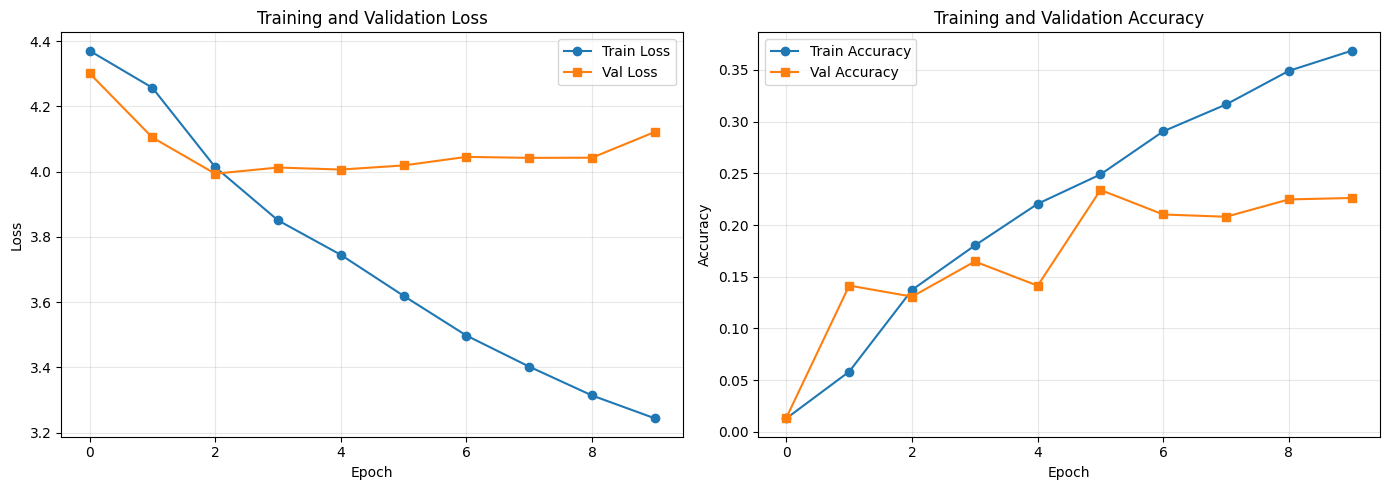

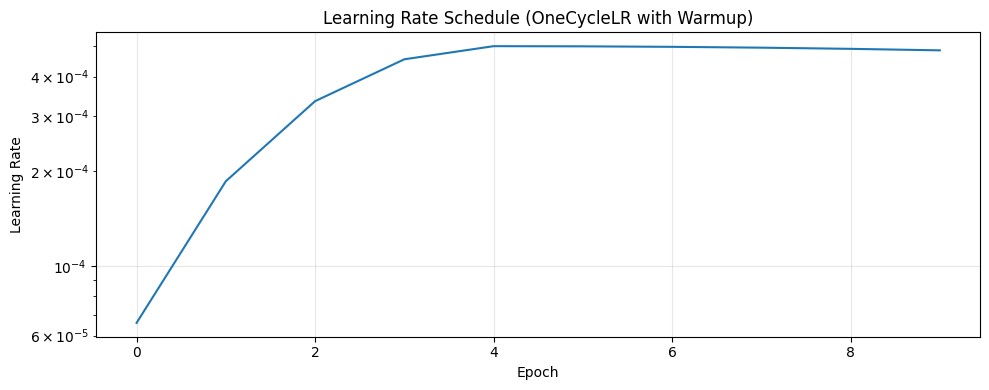

In [20]:
def evaluate_transformer(model, loader):
    """Evaluate transformer model on a dataset."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_score': f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }

    return metrics, all_preds, all_labels


# Evaluate on test set
test_metrics, test_preds, test_labels_list = evaluate_transformer(model, test_loader)

# Print results
print("=" * 80)
print("BERT-STYLE TRANSFORMER - TEST SET PERFORMANCE")
print("=" * 80)
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-Score:  {test_metrics['f1_score']:.4f}")
print("=" * 80)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(results['history']['train_loss'], label='Train Loss', marker='o')
axes[0].plot(results['history']['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(results['history']['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(results['history']['val_acc'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'transformer_bert_k{K}_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot learning rate schedule
plt.figure(figsize=(10, 4))
plt.plot(results['history']['lr'])
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (OneCycleLR with Warmup)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig(f'transformer_bert_k{K}_lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
from sklearn.metrics import classification_report

# Generate classification report for per-class performance
print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE REPORT")
print("=" * 80)
report = classification_report(
    test_labels_list,
    test_preds,
    labels=np.arange(K),
    target_names=[label_to_char[i] for i in np.arange(K)],
    zero_division=0
)
print(report)
print("=" * 80)


PER-CLASS PERFORMANCE REPORT
                    precision    recall  f1-score   support

           Cartman       0.51      0.23      0.32      1503
              Stan       0.39      0.20      0.27      1166
              Kyle       0.50      0.14      0.21      1085
           Butters       0.28      0.27      0.27       408
             Randy       0.27      0.20      0.23       400
      Mr. Garrison       0.08      0.23      0.12       163
              Chef       0.17      0.32      0.22       138
             Kenny       0.07      0.40      0.13       134
            Sharon       0.27      0.32      0.29       134
             Jimmy       0.17      0.27      0.21       102
            Gerald       0.12      0.09      0.10        99
        Mr. Mackey       0.26      0.41      0.32        98
             Liane       0.20      0.37      0.26        90
             Wendy       0.15      0.15      0.15        89
            Sheila       0.24      0.29      0.26        86
         

## 13. Save Model\n\nSave the trained transformer model with full configuration and metrics.

In [22]:
# Save checkpoint
checkpoint = {
    'model_type': 'BERT-style Transformer',
    'model_state_dict': model.state_dict(),
    'config': {
        'K': K,
        'vocab_size': len(vocab),
        'embedding_dim': EMBEDDING_DIM,
        'num_heads': NUM_HEADS,
        'num_layers': NUM_LAYERS,
        'hidden_dim': HIDDEN_DIM,
        'max_seq_len': MAX_SEQ_LEN,
        'dropout_rate': DROPOUT_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'weight_decay': WEIGHT_DECAY
    },
    'char_to_label': char_to_label,
    'label_to_char': label_to_char,
    'vocab': {
        'word2idx': vocab.word2idx,
        'idx2word': vocab.idx2word
    },
    'test_metrics': test_metrics,
    'history': results['history'],
    'training_time': results['time'],
    'total_parameters': sum(p.numel() for p in model.parameters())
}

filename = f'transformer_bert_k{K}.pt'
torch.save(checkpoint, filename)

print(f"Model saved to: {filename}")
print(f"\nModel Summary:")
print(f"  Architecture: BERT-style Transformer Encoder")
print(f"  Parameters: {checkpoint['total_parameters']:,}")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Attention heads: {NUM_HEADS}")
print(f"  Transformer layers: {NUM_LAYERS}")
print(f"  Feedforward dim: {HIDDEN_DIM}")
print(f"  Vocabulary size: {len(vocab):,}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"\nPerformance:")
print(f"  Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  Test F1-Score: {test_metrics['f1_score']:.4f}")
print(f"  Training time: {results['time']/60:.2f} minutes")
print(f"\nComparison with other models:")
print(f"  Load this checkpoint and compare metrics with:")
print(f"    - baseline_logistic_regression.ipynb")
print(f"    - rnn_lstm_gru_models.ipynb")
print(f"    - seq2seq_basic.ipynb")

Model saved to: transformer_bert_k31.pt

Model Summary:
  Architecture: BERT-style Transformer Encoder
  Parameters: 1,939,743
  Embedding dim: 128
  Attention heads: 4
  Transformer layers: 4
  Feedforward dim: 512
  Vocabulary size: 8,062
  Max sequence length: 256

Performance:
  Test Accuracy: 0.2209
  Test F1-Score: 0.1774
  Training time: 65.12 minutes

Comparison with other models:
  Load this checkpoint and compare metrics with:
    - baseline_logistic_regression.ipynb
    - rnn_lstm_gru_models.ipynb
    - seq2seq_basic.ipynb
